# Sales analysis with NumPy — my revision notes

I wrote these so I can come back and revise without re-learning from scratch.
Each section is: **what I need to remember**, then the code I already ran.

The example is five restaurants and four years of sales. One row is one restaurant.

**How to revise**
1. Read the bullets. Cover the code and try to predict the output.
2. Run the cell and check.
3. If I miss it, read only that section again.
4. Finish with the checklist at the bottom.

**Topics in this notebook**
1. How the sales table is laid out
2. `sum`, `min`, `max`, `mean` and `axis`
3. Cumulative sales
4. Vector add, multiply, dot product, angle
5. Matrix multiplication (`*` vs `@`)
6. Identity, inverse, and solving `Ax = b`
7. `np.vectorize` for text
8. Divide every sales number by 12
9. Broadcasting

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. How the sales table is laid out

Each row is one restaurant. Columns are:

`[restaurant_id, 2021, 2022, 2023, 2024]`

Five restaurants, five columns → shape `(5, 5)`.

`sales_data[0:3]` is the first three **rows**. The stop is not included, same as slicing in the last notebook.

The id column is not money. Later I drop it with `[:, 1:]` before any sales math.

In [2]:
# Data structure: [restaurant_id, 2021, 2022, 2023, 2024]
sales_data = np.array(
    [
        [1, 150000, 180000, 220000, 250000],  # Paradise Biryani
        [2, 120000, 140000, 160000, 190000],  # Beijing Bites
        [3, 200000, 230000, 260000, 300000],  # Pizza Hub
        [4, 180000, 210000, 240000, 270000],  # Burger Point
        [5, 160000, 185000, 205000, 230000],  # Chai Point
    ]
)

print(" ===== Sales Analysis ===== ")
print("\n Sales data shape: ", sales_data.shape)
print("\n 1st 3 resturant: ", sales_data[0:3])

 ===== Sales Analysis ===== 

 Sales data shape:  (5, 5)

 1st 3 resturant:  [[     1 150000 180000 220000 250000]
 [     2 120000 140000 160000 190000]
 [     3 200000 230000 260000 300000]]


## 2. `sum`, `min`, `max`, `mean` and `axis`

`axis` says which direction to collapse.

- `axis=0` — down each **column** (across restaurants). One number per year.
- `axis=1` — across each **row** (across years). One number per restaurant.

`sales_data[:, 1:]` drops the id column first. Without that, the first sum adds the ids too: `1+2+3+4+5 = 15`. That `15` is not sales. I keep that mistake in the first print so I remember why the slice is there.

On the sales-only block:

- `np.sum(..., axis=0)` — total sales of all restaurants, one total per year
- `np.min(..., axis=1)` — worst year for each restaurant
- `np.max(..., axis=0)` — best restaurant in each year
- `np.mean(..., axis=1)` — average yearly sales for each restaurant

`mean` returns floats (`200000.`). `sum`, `min`, and `max` stay integers here.

In [3]:
# Total sales for per year
print("\n Total sales for per year: ", np.sum(sales_data, axis=0))

yearly_sales = np.sum(sales_data[:, 1:], axis=0)
print("\n Yearly sales: ", yearly_sales)

# Minimum sales per restaurant
min_sales = np.min(sales_data[:, 1:], axis=1)
print("\n Minimum sales per restaurant: ", min_sales)

# Maximum sales per year
max_sales = np.max(sales_data[:, 1:], axis=0)
print("\n Maximum sales per year: ", max_sales)

# Average sales per restaurant
avg_sales = np.mean(sales_data[:, 1:], axis=1)
print("\n Average sales per restaurant: ", avg_sales)


 Total sales for per year:  [     15  810000  945000 1085000 1240000]

 Yearly sales:  [ 810000  945000 1085000 1240000]

 Minimum sales per restaurant:  [150000 120000 200000 180000 160000]

 Maximum sales per year:  [200000 230000 260000 300000]

 Average sales per restaurant:  [200000. 152500. 247500. 225000. 195000.]


## 3. Cumulative sales

`np.cumsum(..., axis=1)` adds along the row, left to right.
Each cell is "sales so far" for that restaurant.

Paradise Biryani: `150000`, then `150000+180000 = 330000`, then `330000+220000 = 550000`, then `550000+250000 = 800000`.
The last column is the four-year total for that restaurant.

The plot takes `np.mean(cumsum, axis=0)`: average of those running totals across the five restaurants, one point per year.

Cumulative sales: 
 [[150000 330000 550000 800000]
 [120000 260000 420000 610000]
 [200000 430000 690000 990000]
 [180000 390000 630000 900000]
 [160000 345000 550000 780000]]


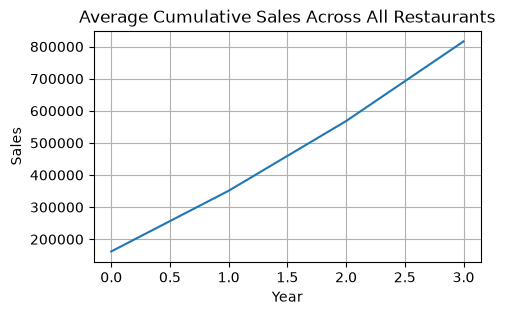

In [4]:
# Cumulative sales
cumsum = np.cumsum(sales_data[:, 1:], axis=1)
print("Cumulative sales: \n", cumsum)

# Plotting the sales data
plt.figure(figsize=(5, 3))
plt.plot(np.mean(cumsum, axis=0))
plt.title("Average Cumulative Sales Across All Restaurants")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# Growth rate

## 4. Vector add, multiply, dot product, angle

`vector1 = [1, 2, 3, 4, 5]`, `vector2 = [6, 7, 8, 9, 10]`.

- `+` adds item by item → `[7, 9, 11, 13, 15]`
- `*` multiplies item by item → `[6, 14, 24, 36, 50]`
- `np.dot` is one number: `1*6 + 2*7 + 3*8 + 4*9 + 5*10 = 130`
- The angle (in radians) comes from

  `cos(angle) = dot(a, b) / (length(a) * length(b))`

  so `angle = arccos(...)`. Here it is about `0.27` radians, a small angle, so the two vectors point in a similar direction.

`np.linalg.norm` is the length of a vector.

In [5]:
vector1 = np.array([1, 2, 3, 4, 5])
vector2 = np.array([6, 7, 8, 9, 10])

print("Vector addition: ", vector1 + vector2)
print("\n Multiplication vector: ", vector1 * vector2)
print("\n dot product: ", np.dot(vector1, vector2))

angle = np.arccos(np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2)))
print("\n Angle between vectors: ", angle)

Vector addition:  [ 7  9 11 13 15]

 Multiplication vector:  [ 6 14 24 36 50]

 dot product:  130

 Angle between vectors:  0.26554161733900966


## 5. Matrix multiplication

`*` and `@` are different.

- `A * B` multiplies **matching cells**. Shapes must already match, or broadcast.
- `A @ B` is a **matrix product**. The inner sizes must match: `(2, 2) @ (2, 2)` works. The result shape is `(2, 2)`.

```
A = [[1, 2],
     [3, 4]]
B = [[10, 20],
     [30, 40]]
```

`A * B` → `[[10, 40], [90, 160]]`

`A @ B` → `[[70, 100], [150, 220]]`

The top-left `70` is one dot product: row `[1, 2]` with column `[10, 30]` → `1*10 + 2*30 = 70`.

`np.matmul(A, B)` is the same as `A @ B`. `np.dot` on these two matrices does this too. On two 1D vectors, `np.dot` is still the single number from section 4.


In [6]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[10, 20], [30, 40]])

print("Item by item:", A * B)
print("Matrix product:\n", A @ B)


Item by item: [[ 10  40]
 [ 90 160]]
Matrix product:
 [[ 70 100]
 [150 220]]


## 6. Identity, inverse, and solving `Ax = b`

These three sit on top of the matrix product.

- `np.eye(2)` is the identity. Ones on the diagonal, zeros elsewhere. `A @ I` gives `A` back.
- `np.linalg.inv(A)` is the inverse. `A @ inv(A)` gives the identity. `A` must be square, and it must be invertible. I use floats here so the inverse is not forced into integers. The printed check is rounded, because the raw product can leave a leftover around `1e-16`.
- `np.linalg.solve(A, b)` solves `Ax = b` for `x`. It is the tool I use instead of computing the inverse myself.

For `A = [[1, 2], [3, 4]]` and `b = [5, 11]`:

- `x + 2y = 5`
- `3x + 4y = 11`

The solution is `x = 1`, `y = 2`.


In [7]:
identity = np.eye(2)
print("Identity:\n", identity)

A_float = np.array([[1.0, 2.0], [3.0, 4.0]])
inverse = np.linalg.inv(A_float)
print("Inverse:\n", inverse)
print("A @ inverse:\n", np.round(A_float @ inverse, decimals=10))

b = np.array([5.0, 11.0])
solution = np.linalg.solve(A_float, b)
print("Solution:", solution)


Identity:
 [[1. 0.]
 [0. 1.]]
Inverse:
 [[-2.   1. ]
 [ 1.5 -0.5]]
A @ inverse:
 [[1. 0.]
 [0. 1.]]
Solution: [1. 2.]


## 7. `np.vectorize` for text

NumPy math works on numbers directly. A normal Python function, like `str.upper`, does not.

`np.vectorize(str.upper)` wraps that function so it runs on every item:

`["biryani", "chinese", ...]` → `['BIRYANI', 'CHINESE', ...]`

This is for convenience. It is still a Python loop inside, so it is not the fast path I use for numeric work.

In [8]:
restaurant_types = np.array(["biryani", "chinese", "pizza", "burger", "chai"])
vectorized_upper = np.vectorize(str.upper)
print("\n Uppercase restaurant types: ", vectorized_upper(restaurant_types))


 Uppercase restaurant types:  ['BIRYANI' 'CHINESE' 'PIZZA' 'BURGER' 'CHAI']


## 8. Divide every sales number by 12

`sales_data[:, 1:] / 12` divides **each** yearly sales number by 12.
That is a rough monthly average. I do not write a loop.

Dividing integers by an integer can still produce floats, because `12` does not always divide the sales evenly. Example: `220000 / 12 = 18333.333...`.

The id column is sliced off again. Dividing the restaurant id by 12 would be meaningless.

In [9]:
monthly_avg = sales_data[:, 1:] / 12
print("\n Monthly average sales: \n", monthly_avg)


 Monthly average sales: 
 [[12500.         15000.         18333.33333333 20833.33333333]
 [10000.         11666.66666667 13333.33333333 15833.33333333]
 [16666.66666667 19166.66666667 21666.66666667 25000.        ]
 [15000.         17500.         20000.         22500.        ]
 [13333.33333333 15416.66666667 17083.33333333 19166.66666667]]


## 9. Broadcasting

Section 8 divides a `(5, 4)` table by the single number `12`. NumPy stretches that `12` across every cell. That stretch is **broadcasting**.

Compare shapes from the **right**.

- A dimension of size `1` can stretch.
- A missing dimension on the left can stretch.
- Any other mismatch is an error.

Small table, shape `(2, 3)`:

```
[[10, 20, 30],
 [40, 50, 60]]
```

- A row `[1, 2, 3]` has shape `(3,)`. The rightmost sizes are both `3`, so each column is scaled. `20 * 2 = 40`.
- A column `[[10], [100]]` has shape `(2, 1)`. The `1` stretches across the 3 columns, so each row gets one added number.
- A row of length `2` does **not** fit a width of `3`. That raises `ValueError`.

In `02_slicing_sorting.ipynb`, stacking still needs identical shapes. Broadcasting is only for arithmetic.


In [10]:
small = np.array([[10, 20, 30], [40, 50, 60]])
row = np.array([1, 2, 3])
column = np.array([[10], [100]])

print("Scale each column:\n", small * row)
print("Add one number per row:\n", small + column)


Scale each column:
 [[ 10  40  90]
 [ 40 100 180]]
Add one number per row:
 [[ 20  30  40]
 [140 150 160]]


## Revision checklist

Cover the answers. Say them out loud. Then uncover.

1. What does shape `(5, 5)` mean here, and why do I use `[:, 1:]` before sales math?
2. `axis=0` or `axis=1` — which one gives one number per restaurant?
3. What is the last column of `cumsum` along `axis=1`?
4. How is a dot product different from `vector1 * vector2`?
5. What does `np.vectorize` do, and is it the fast numeric path?
6. What does `sales_data[:, 1:] / 12` do to the table?
7. On two matrices, how is `A * B` different from `A @ B`?
8. What does `np.linalg.solve(A, b)` return?
9. Shapes `(2, 3)` and `(3,)` — does broadcasting work? What about `(2, 3)` and `(2,)`?

<details>
<summary>Answers</summary>

1. 5 restaurants, 5 columns. `[:, 1:]` drops the id column so ids are not added into the money.
2. `axis=1`. It walks across each row. `axis=0` walks down each column.
3. The four-year total for that restaurant.
4. `*` makes a new vector, item by item. `np.dot` multiplies matching items and **adds them into one number**.
5. It runs a Python function on every item. It is still a Python loop, not fast array math.
6. It divides every yearly sales number by 12. Shape stays `(5, 4)`. That is broadcasting a single number.
7. `*` multiplies matching cells. `@` is the matrix product: each result cell is a dot product of a row and a column.
8. The vector `x` that solves `Ax = b`.
9. `(2, 3)` and `(3,)` works, because the rightmost sizes match. `(2, 3)` and `(2,)` fails, because `3` and `2` do not match.

</details>

**Still to add later:** the growth-rate calculation that the code comment marks but does not compute yet.